In [ ]:
'''
Author: David Brin
Date Created: 9/24/2024

This notebook is for comparing findings for plate A across recording days, comparing findings at different time points
Comparing firing rates, spiking activity 
'''

In [2]:
%run "./A_LFP_analysis_functions.py"

C:\Users\david\Documents\Voytek Research\psychedelic_organoids\PlateA\A_LFP_analysis_functions.py:54: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [8]:
lfp_data = load_lfp(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D\poststim_lfp_data.h5")
spike_times = load_spikes(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D1\spike_data.mat")

(2, 3, 86500)
dict_keys(['__header__', '__version__', '__globals__', 'None', 'spike_times', 'spike_waveforms', '__function_workspace__'])


In [24]:
lfp_data0 = load_lfp(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D0\prestim_lfp_data.h5")
spike_times0 = load_spikes(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D0\prestim_spike_data.mat")
lfp_data1 = load_lfp(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D0\poststim_lfp_data.h5")
spike_times1 = load_spikes(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D0\prestim_spike_data.mat")
lfp_data2 = load_lfp(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D1\poststim_lfp_data.h5")
spike_times2 = load_spikes(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D1\spike_data.mat")
lfp_data3 = load_lfp(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D4\poststimd4_lfp_data.h5")
spike_times3 = load_spikes(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D4\spike_data.mat")
lfp_data4 = load_lfp(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D6\poststim_d6_lfp_data.h5")
spike_times4 = load_spikes(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D6\spike_data.mat")
lfp_data5 = load_lfp(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D18\d18_lfp_data.h5")
spike_times5 = load_spikes(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D18\spike_data_10min.mat")
lfp_data6 = load_lfp(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D20\d20_lfp_data.h5")
spike_times6 = load_spikes(r"C:\Users\david\Documents\Voytek Research\LFP_psych_proj\PlateA\PlateA_D20\spike_data_10min.mat")

(2, 3, 61475)
dict_keys(['__header__', '__version__', '__globals__', 'None', 'spike_times', 'spike_waveforms', '__function_workspace__'])
(2, 3, 86500)
dict_keys(['__header__', '__version__', '__globals__', 'None', 'spike_times', 'spike_waveforms', '__function_workspace__'])
(2, 3, 60325)
dict_keys(['__header__', '__version__', '__globals__', 'None', 'spike_times', 'spike_waveforms', '__function_workspace__'])
(2, 3, 60000)
dict_keys(['__header__', '__version__', '__globals__', 'None', 'spike_times', 'spike_waveforms', '__function_workspace__'])
(2, 3, 62775)
dict_keys(['__header__', '__version__', '__globals__', 'None', 'spike_times', 'spike_waveforms', '__function_workspace__'])
(2, 3, 77850)
dict_keys(['__header__', '__version__', '__globals__', 'None', 'spike_times', 'spike_waveforms', '__function_workspace__'])
(2, 3, 60850)
dict_keys(['__header__', '__version__', '__globals__', 'None', 'spike_times', 'spike_waveforms', '__function_workspace__'])


In [25]:
lfp_datas = [lfp_data0, lfp_data1, lfp_data2, lfp_data3, lfp_data4, lfp_data5, lfp_data6]
spike_timess = [spike_times0, spike_times1, spike_times2, spike_times3, spike_times4, spike_times5, spike_times6]

In [32]:
def compare_spike_heatmaps_across_files(spike_times_files):
    '''
    Plot side-by-side heatmaps for each spike_times_array from multiple files with a consistent color scale.
    spike_times_files: list of spike_times_array for each file
    '''
    num_files = len(spike_times_files)
    
    # Step 1: Calculate global vmin and vmax
    global_min = np.inf
    global_max = -np.inf

    for spike_times_array in spike_times_files:
        for row in range(2):
            for col in range(3):
                for i in range(4):
                    for j in range(4):
                        if spike_times_array[row, col, i, j] is not None and spike_times_array[row, col, i, j].size > 0:
                            spike_times = spike_times_array[row, col, i, j][0]
                            count = len(spike_times)
                            if count < global_min:
                                global_min = count
                            if count > global_max:
                                global_max = count

    # Step 2: Plot the heatmaps using global vmin and vmax
    fig, axs = plt.subplots(1, num_files, figsize=(num_files * 4, 6))

    for file_idx, spike_times_array in enumerate(spike_times_files):
        heatmap_data = np.zeros((2, 3))

        for row in range(2):
            for col in range(3):
                sub_heatmap_data = np.zeros((4, 4))
                for i in range(4):
                    for j in range(4):
                        if spike_times_array[row, col, i, j] is not None and spike_times_array[row, col, i, j].size > 0:
                            spike_times = spike_times_array[row, col, i, j][0]
                            sub_heatmap_data[i, j] = len(spike_times)
                heatmap_data[row, col] = np.sum(sub_heatmap_data)

        # Plot heatmap for each file with consistent scale
        im = axs[file_idx].imshow(heatmap_data, cmap='hot', interpolation='nearest', vmin=global_min, vmax=global_max)
        axs[file_idx].set_title(f'File {file_idx + 1}')
        axs[file_idx].axis('off')
    
    # Step 3: Add a unified colorbar based on the last heatmap (mappable 'im')
    plt.suptitle('Spike Count Heatmap Progression Across Files')
    fig.colorbar(im, ax=axs, label='Number of Spikes', fraction=0.02, pad=0.04)
    plt.show()


In [36]:
def firing_rate_per_well(spike_times_files, lfp_data_files):
    '''
    Plot firing rate per well across multiple files.
    spike_times_files: list of spike_times_array from each file
    lfp_data_files: list of lfp_data corresponding to each file
    '''
    num_files = len(spike_times_files)
    wells_firing_rate = np.zeros((2, 3, num_files))  # 2x3 grid for wells, across time

    # Loop through each file to calculate the firing rate
    for file_idx, spike_times_array in enumerate(spike_times_files):
        lfp_data = lfp_data_files[file_idx]

        for row in range(2):
            for col in range(3):
                total_spikes = 0
                total_duration_sec = len(lfp_data[row, col]) / 100  # assuming 100 Hz sampling rate

                # Sum spikes across all electrodes in the well
                for i in range(4):
                    for j in range(4):
                        if spike_times_array[row, col, i, j] is not None and len(spike_times_array[row, col, i, j]) > 0:
                            total_spikes += len(spike_times_array[row, col, i, j][0])

                # Compute firing rate
                firing_rate = total_spikes / total_duration_sec
                wells_firing_rate[row, col, file_idx] = firing_rate

    # Plotting firing rate for each well over time
    time_points = [f'Time {i + 1}' for i in range(num_files)]

    plt.figure(figsize=(12, 8))
    
    for row in range(2):
        for col in range(3):
            plt.plot(time_points, wells_firing_rate[row, col, :], label=f'Well {row + 1}-{col + 1}')
    
    plt.xlabel('Time Points')
    plt.ylabel('Firing Rate (spikes/sec)')
    plt.title('Firing Rate per Well Across Time')
    plt.legend()
    plt.show()


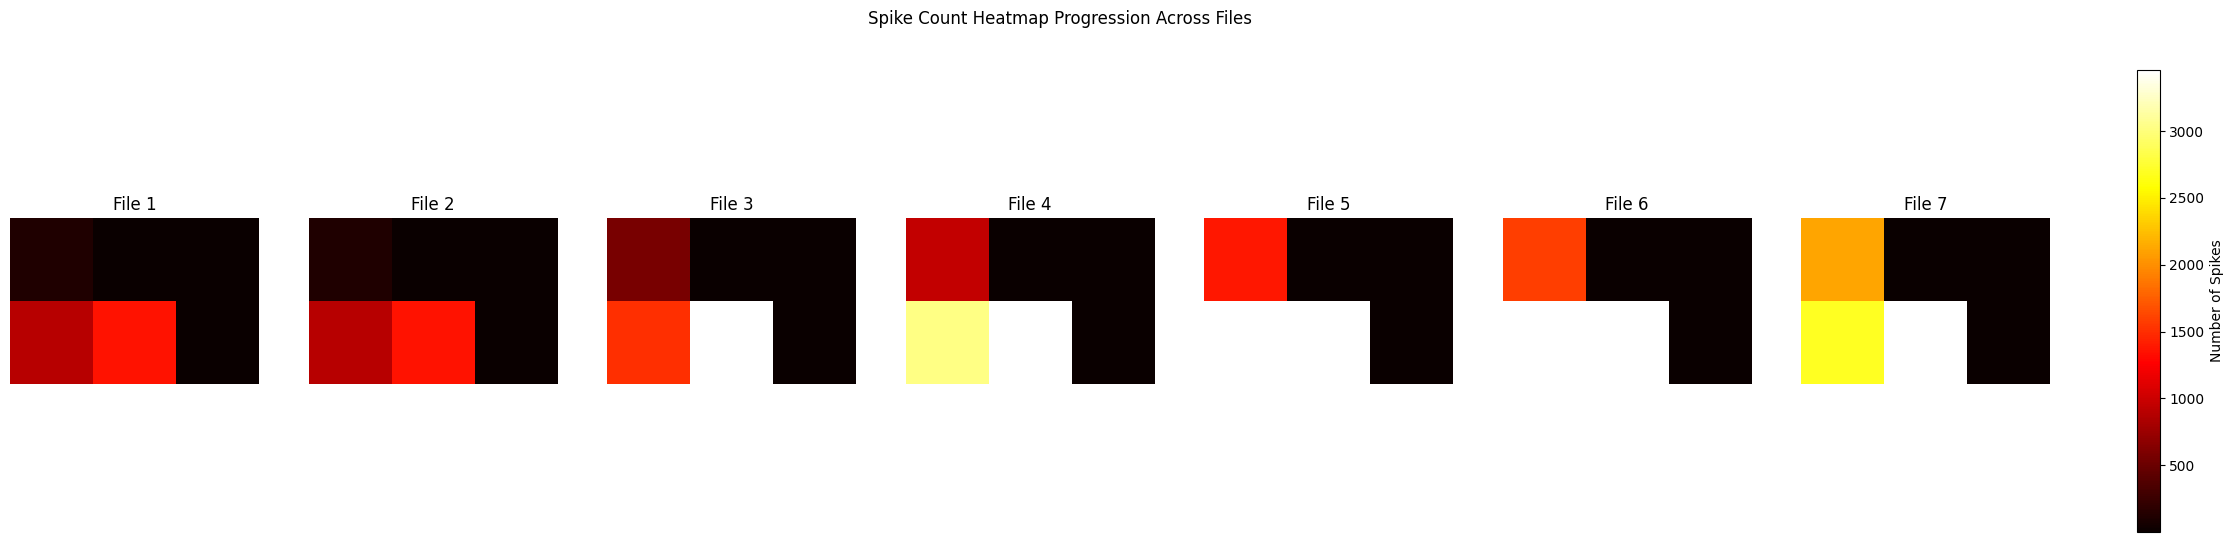

In [37]:
compare_spike_heatmaps_across_files(spike_timess)

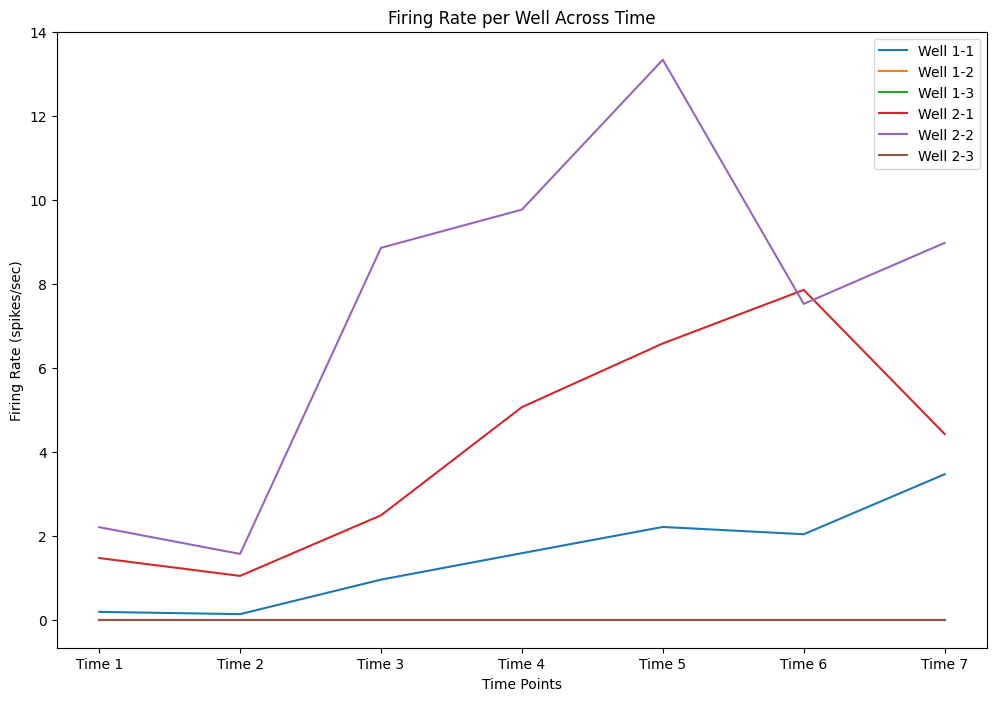

In [39]:
firing_rate_per_well(spike_timess, lfp_datas) # (none-zero)